#importing libraries

In [ ]:

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#Load dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/wfp_food_prices_uga.csv')
df.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2006-01-15,Kampala,Central Kampala,Owino,258,0.32,32.57,cereals and tubers,Maize,51,KG,actual,Wholesale,UGX,345.42,0.20
1,2006-01-15,Kampala,Central Kampala,Owino,258,0.32,32.57,cereals and tubers,Rice,52,KG,actual,Wholesale,UGX,1013.40,0.58
2,2006-01-15,Lira,Lira Municipality,Lira,263,2.23,32.91,cereals and tubers,Maize,51,KG,actual,Wholesale,UGX,247.76,0.14
3,2006-02-15,Kampala,Central Kampala,Owino,258,0.32,32.57,cereals and tubers,Maize,51,KG,actual,Wholesale,UGX,347.23,0.20
4,2006-02-15,Kampala,Central Kampala,Owino,258,0.32,32.57,cereals and tubers,Rice,52,KG,actual,Wholesale,UGX,1028.64,0.59


# Data exploration

In [ ]:
df.shape

(30933, 16)

In [ ]:
df.columns

Index(['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude',
       'longitude', 'category', 'commodity', 'commodity_id', 'unit',
       'priceflag', 'pricetype', 'currency', 'price', 'usdprice'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30933 entries, 0 to 30932
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          30933 non-null  object 
 1   admin1        30933 non-null  object 
 2   admin2        30933 non-null  object 
 3   market        30933 non-null  object 
 4   market_id     30933 non-null  int64  
 5   latitude      30933 non-null  float64
 6   longitude     30933 non-null  float64
 7   category      30933 non-null  object 
 8   commodity     30933 non-null  object 
 9   commodity_id  30933 non-null  int64  
 10  unit          30933 non-null  object 
 11  priceflag     30933 non-null  object 
 12  pricetype     30933 non-null  object 
 13  currency      30933 non-null  object 
 14  price         30933 non-null  float64
 15  usdprice      30933 non-null  float64
dtypes: float64(4), int64(2), object(10)
memory usage: 3.8+ MB


In [ ]:
df.describe()

,market_id,latitude,longitude,commodity_id,price,usdprice
count,30933.000000,30933.000000,30933.000000,30933.000000,30933.000000,30933.000000
mean,4333.970743,1.645041,32.086980,326.604856,3206.921675,0.891019
std,2765.616358,1.462021,1.241445,370.573380,3762.452719,1.019973
min,257.000000,-1.250000,29.990000,50.000000,2.000000,0.000570
25%,264.000000,0.360000,31.030000,67.000000,1200.000000,0.350000
50%,6405.000000,1.710000,31.770000,76.000000,2000.000000,0.580000
75%,6411.000000,3.230000,32.910000,758.000000,3583.000000,0.990000
max,7957.000000,3.570000,34.830000,1006.000000,66608.000000,18.150000


In [ ]:
df.sample(5)

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
14742,2023-01-15,Nakapiripirit,Kadani,Namalu,2347,1.79,34.60,cereals and tubers,Maize flour,76,KG,actual,Retail,UGX,3075.0,0.84
4088,2017-05-15,Kampala,Central Kampala,Owino,258,0.32,32.57,cereals and tubers,Cassava flour,74,KG,actual,Wholesale,UGX,1500.0,0.41
27294,2025-07-15,Abim,Labwor,Makaratin,2343,2.71,33.64,cereals and tubers,Millet,73,KG,actual,Retail,UGX,3450.0,0.96
533,2011-01-15,Mbarara,Mbarara Municipality,Mbarara,264,-0.61,30.65,cereals and tubers,Cassava flour,74,KG,actual,Retail,UGX,1050.0,0.44
14148,2022-12-15,Kamwenge,Kibale,Rwamwanja (refugee settlement),6410,0.31,30.68,non-food,Wooden mingle,1006,Unit,actual,Retail,UGX,1000.0,0.27


In [ ]:
# Explore categorical variables
for col in ['category', 'commodity', 'unit', 'priceflag', 'pricetype', 'currency']:
    print(f"\n{col}")
    print(df[col].value_counts())


category
category
cereals and tubers       14321
non-food                  7549
pulses and nuts           3237
oil and fats              2519
vegetables and fruits     1046
meat, fish and eggs        780
miscellaneous food         771
milk and dairy             710
Name: count, dtype: int64

commodity
commodity
Beans                       3237
Maize flour                 2892
Maize (white)               2717
Sorghum                     2628
Oil (vegetable)             2519
Cassava flour               2073
Millet                      1606
Millet flour                 794
Fish (dry)                   780
Salt                         771
Leafy vegetables             765
Cassava (fresh)              734
Milk (fresh)                 710
Laundry soap                 684
Maize                        682
Underwear                    670
Charcoal                     665
Firewood                     661
Sanitary pads                600
Jerrycan (20 L)              286
Mug (plastic)             

In [ ]:
# Check food and non-food categories
df['category'].value_counts()

,count
category,
cereals and tubers,14321
non-food,7549
pulses and nuts,3237
oil and fats,2519
vegetables and fruits,1046
"meat, fish and eggs",780
miscellaneous food,771
milk and dairy,710


Data cleaning

The dataset originally contained both food and non-food products. Since the objective of this study is to predict food commodity prices, non-food records were removed before further analysis

In [ ]:
# Remove non-food products
df = df[df['category'] != 'non-food']

# Verify that non-food has been removed
df['category'].value_counts()

,count
category,
cereals and tubers,14321
pulses and nuts,3237
oil and fats,2519
vegetables and fruits,1046
"meat, fish and eggs",780
miscellaneous food,771
milk and dairy,710


In [ ]:
#check for missing values
df.isnull().sum()

,0
date,0
admin1,0
admin2,0
market,0
market_id,0
latitude,0
longitude,0
category,0
commodity,0
commodity_id,0


In [ ]:
#check for dulicated rows
df.duplicated().sum()

np.int64(0)

In [ ]:
#check data types
df.dtypes

,0
date,object
admin1,object
admin2,object
market,object
market_id,int64
latitude,float64
longitude,float64
category,object
commodity,object
commodity_id,int64


# Convert the Date Column to datetime format
In order to analyze trends over time,
extract the year and month to
create time-series visualizations.

In [ ]:
df.loc[:,'date'] = pd.to_datetime(df['date'])
df.dtypes

,0
date,object
admin1,object
admin2,object
market,object
market_id,int64
latitude,float64
longitude,float64
category,object
commodity,object
commodity_id,int64


In [ ]:
df['date'].head()

,date
0,2006-01-15 00:00:00
1,2006-01-15 00:00:00
2,2006-01-15 00:00:00
3,2006-02-15 00:00:00
4,2006-02-15 00:00:00


Inspected the Remaining Categorical Columns in order to guide me decide whether these columns add useful information before buiding the model.

In [ ]:
df['priceflag'].value_counts()

,count
priceflag,
actual,23384


In [ ]:
df['pricetype'].value_counts()

,count
pricetype,
Retail,22088
Wholesale,1296


In [ ]:
df['currency'].value_counts()

,count
currency,
UGX,23384


The pricetype column contains two different values.

That means the price may differ depending on whether it is Retail or Wholesale.

This information can help the model and so it was kept while priceflag and currency columns were dropped since they have one value and a machine learning model cannot learn anything from a column that has the same value in every row.

In [ ]:
# Remove unnecessary columns
df = df.drop(columns=['priceflag', 'currency'])

# Check the remaining columns
df.columns

Index(['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude',
       'longitude', 'category', 'commodity', 'commodity_id', 'unit',
       'pricetype', 'price', 'usdprice'],
      dtype='object')



In order, to avoid data leakage, I removed the Usd price as well since it is simply the price converted into US dollars

In [ ]:
# Remove usdprice
df = df.drop(columns=['usdprice'])

# Check the remaining columns
df.columns

Index(['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude',
       'longitude', 'category', 'commodity', 'commodity_id', 'unit',
       'pricetype', 'price'],
      dtype='object')

Also, market ID and Commodity Id were dropped since they are just arbitrary numbers and don't represent meaningful numeric relationships.Instead, I would  later encode the names (market and commodity) into numeric values for the machine learning model

In [ ]:
# Remove identifier columns
df = df.drop(columns=['market_id', 'commodity_id'])

# Check the remaining columns
df.columns

Index(['date', 'admin1', 'admin2', 'market', 'latitude', 'longitude',
       'category', 'commodity', 'unit', 'pricetype', 'price'],
      dtype='object')

Exploratory Data Analysis (EDA)

 # Summary Statistics

In [ ]:
df.describe()

,latitude,longitude,price
count,23384.000000,23384.000000,23384.000000
mean,1.555033,32.336217,3296.239752
std,1.390329,1.301108,4008.871959
min,-1.250000,29.990000,2.000000
25%,0.360000,31.090000,1375.000000
50%,1.430000,32.310000,2000.000000
75%,3.000000,33.470000,3500.000000
max,3.570000,34.830000,66608.000000


In [ ]:
df.describe(include='all')

/tmp/ipykernel_429/2884002236.py:1: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  df.describe(include='all')


,date,admin1,admin2,market,latitude,longitude,category,commodity,unit,pricetype,price
count,23384,23384,23384,23384,23384.000000,23384.000000,23384,23384,23384,23384,23384.000000
unique,244,37,40,43,NaN,NaN,7,16,2,2,NaN
top,2024-06-15 00:00:00,Kampala,Central Kampala,Owino,NaN,NaN,cereals and tubers,Beans,KG,Retail,NaN
freq,315,1888,1888,1888,NaN,NaN,14321,3237,20155,22088,NaN
mean,NaN,NaN,NaN,NaN,1.555033,32.336217,NaN,NaN,NaN,NaN,3296.239752
std,NaN,NaN,NaN,NaN,1.390329,1.301108,NaN,NaN,NaN,NaN,4008.871959
min,NaN,NaN,NaN,NaN,-1.250000,29.990000,NaN,NaN,NaN,NaN,2.000000
25%,NaN,NaN,NaN,NaN,0.360000,31.090000,NaN,NaN,NaN,NaN,1375.000000
50%,NaN,NaN,NaN,NaN,1.430000,32.310000,NaN,NaN,NaN,NaN,2000.000000
75%,NaN,NaN,NaN,NaN,3.000000,33.470000,NaN,NaN,NaN,NaN,3500.000000


Distribution of Numerical Variables

In [ ]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
numerical_columns

Index(['latitude', 'longitude', 'price'], dtype='object')

Distribution of Food Prices

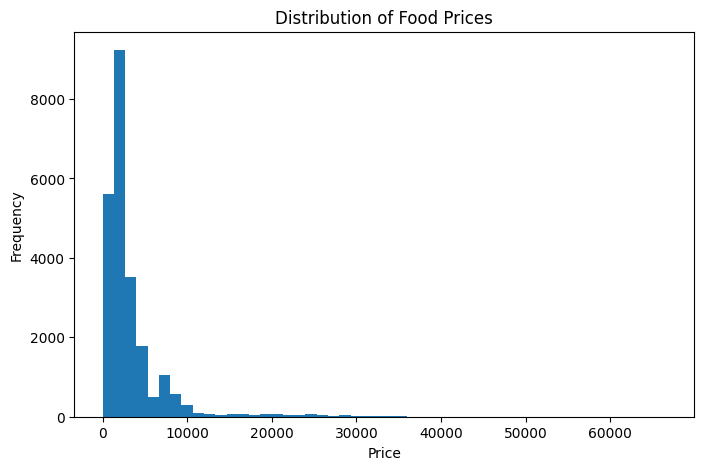

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=50)
plt.title('Distribution of Food Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

The histogram shows that food prices are not normally distributed. Most food prices are relatively low, while a smaller number of observations have much higher prices, resulting in a positively (right) skewed distribution. This indicates substantial variation in food prices and the presence of relatively high-priced observations.

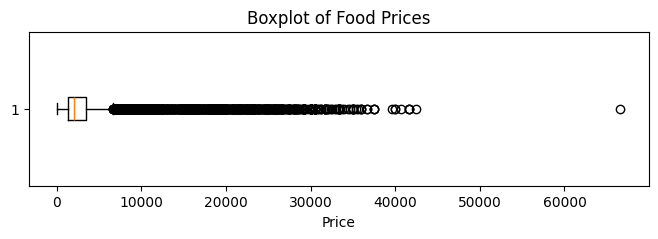

In [ ]:
plt.figure(figsize=(8,2))
plt.boxplot(df['price'], vert=False)
plt.title('Boxplot of Food Prices')
plt.xlabel('Price')
plt.show()

The boxplot shows that most food prices are concentrated within a relatively narrow range, while several extreme high-price outliers extend to approximately UGX 65,000. These outliers indicate that some observations have substantially higher prices than the majority of the dataset. This suggests that food prices are unevenly distributed and that certain commodities, markets, or price conditions may contribute to the extreme values.

# Average Food Price by Commodity

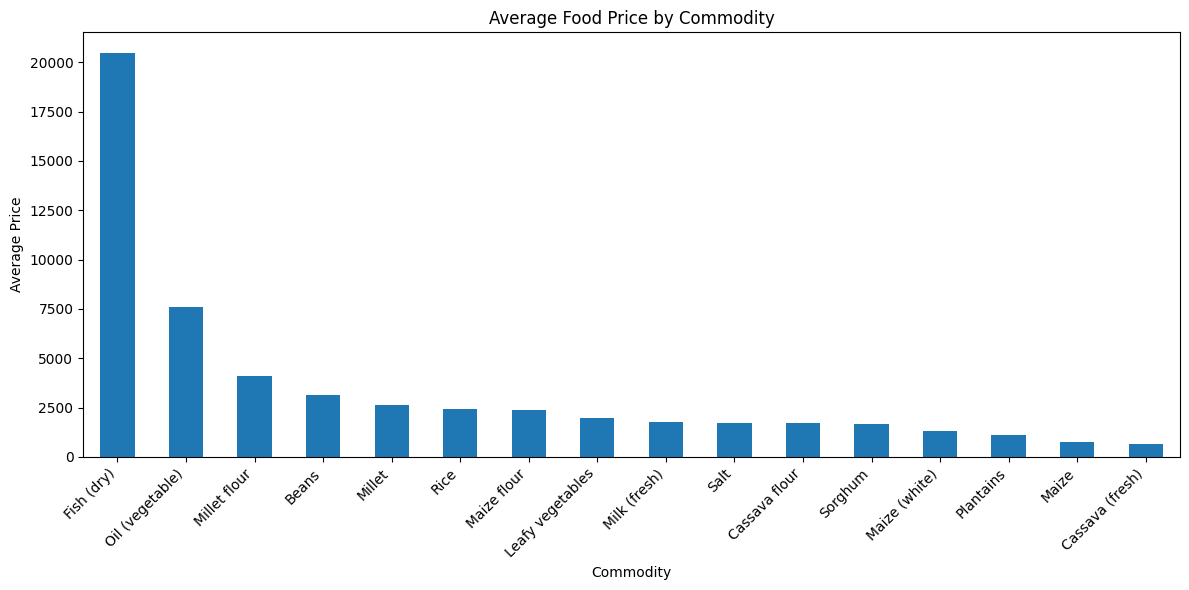

In [ ]:
import matplotlib.pyplot as plt

# Calculate average price by commodity
commodity_price = (
    df.groupby('commodity')['price']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
commodity_price.plot(kind='bar')

plt.title('Average Food Price by Commodity')
plt.xlabel('Commodity')
plt.ylabel('Average Price')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

The bar chart shows clear differences in the average prices of food commodities. Fish (dry) has the highest average price, exceeding UGX 20,000, while fresh cassava has the lowest average price. Dry fish and vegetable oil are notably more expensive than many of the other commodities. This variation suggests that commodity type is strongly associated with food-price differences and may provide an important predictive feature for the machine learning model.

Average Food Price by Market

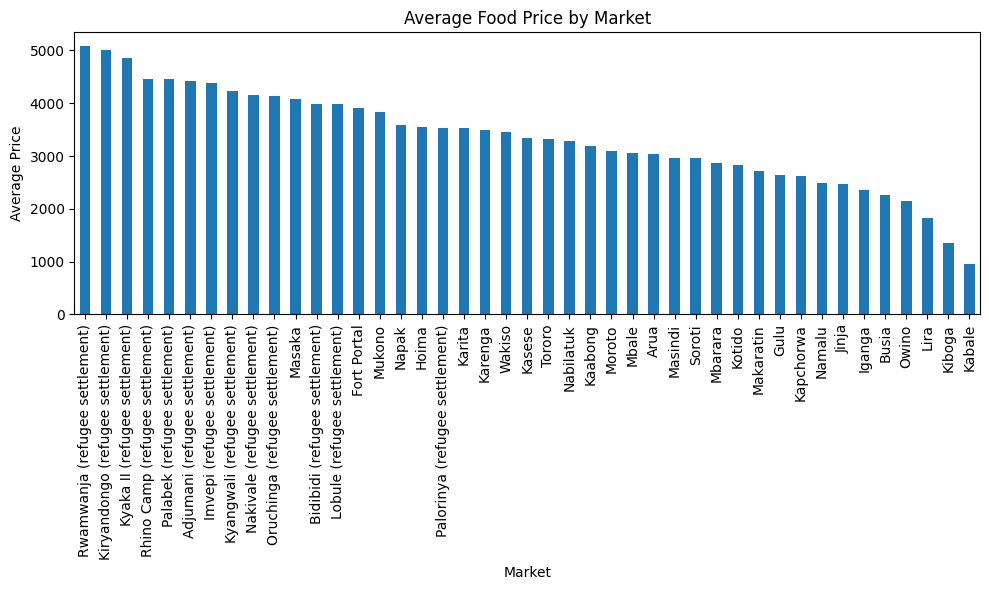

In [ ]:
# Calculate average price by market
market_price = (
    df.groupby('market')['price']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
market_price.plot(kind='bar')

plt.title('Average Food Price by Market')
plt.xlabel('Market')
plt.ylabel('Average Price')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

The bar chart shows that average food prices vary across markets. Rwamwanja has the highest average food price, while Kabale has the lowest. There is a substantial difference between the highest- and lowest-priced markets, suggesting that market-level factors may be associated with differences in food prices. These differences could reflect factors such as transportation costs, supply and demand, accessibility, and local economic conditions. Therefore, market-related information may provide useful predictive features for the machine learning mo



Average Food Price by Category

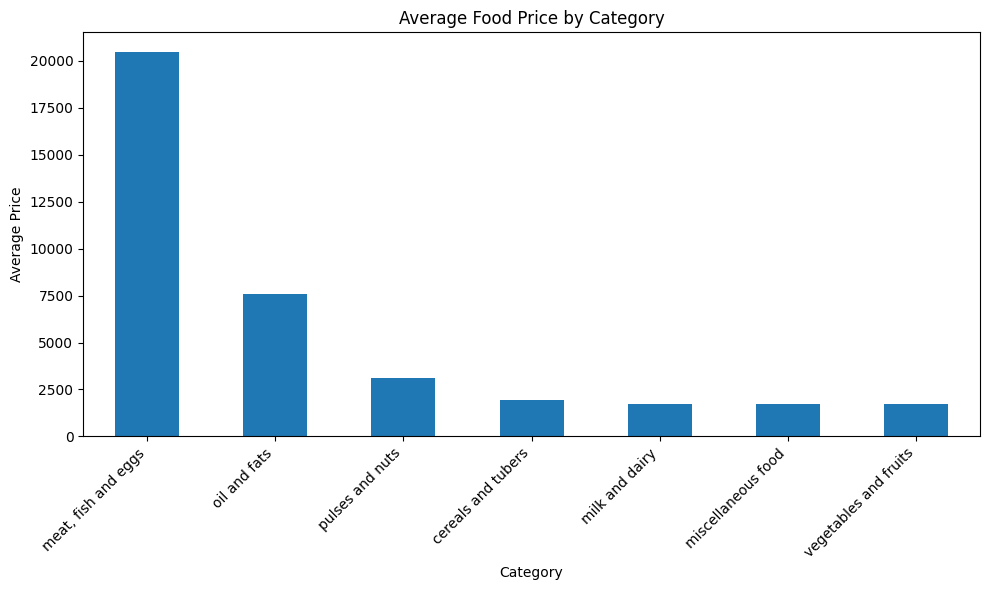

In [ ]:
# Calculate average price by category
category_price = (
    df.groupby('category')['price']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
category_price.plot(kind='bar')

plt.title('Average Food Price by Category')
plt.xlabel('Category')
plt.ylabel('Average Price')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

The bar chart shows noticeable differences in average prices across food categories. The Meat, Fish and Eggs category has the highest average price, exceeding UGX 20,000, while Vegetables and Fruits have the lowest average price. Meat, Fish and Eggs and Oils and Fats also have substantially higher average prices than the other categories, which are relatively lower and more similar. These findings suggest that food category is associated with differences in food prices and may provide useful information for the machine learning model.

Food Price Trends Over Time

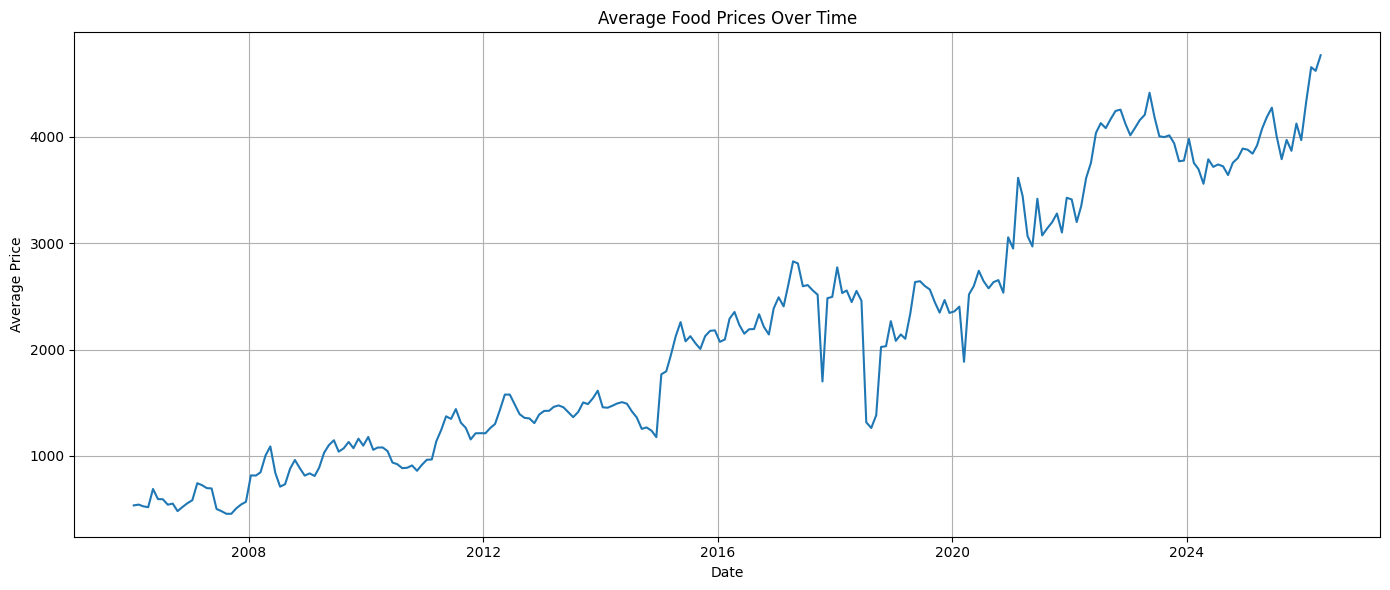

In [ ]:
# Calculate average price by date
price_trend = (
    df.groupby('date')['price']
      .mean()
)

plt.figure(figsize=(14,6))

plt.plot(price_trend)

plt.title('Average Food Prices Over Time')

plt.xlabel('Date')

plt.ylabel('Average Price')

plt.grid(True)

plt.tight_layout()

plt.show()

The line chart shows a clear upward trend in average food prices from 2006 to 2025, increasing from approximately UGX 500 to over UGX 4,500. However, the overall trend is accompanied by considerable volatility, with several noticeable declines, particularly around 2008, 2018, and 2020, followed by periods of recovery. Overall, food prices generally increased over time while experiencing periodic fluctuations. This suggests that time-related features may capture important temporal patterns in food prices and provide useful information for the machine learning model.

Correlation Analysis

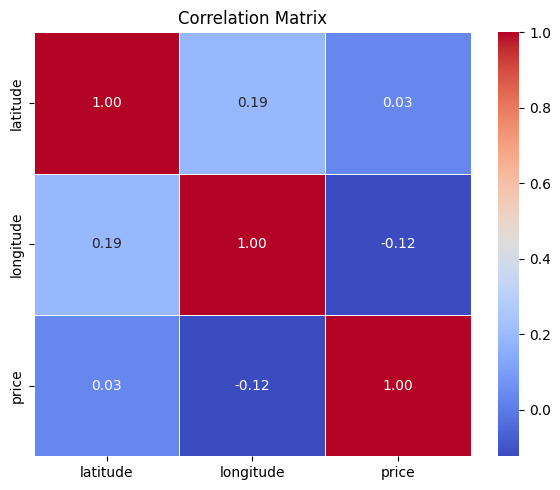

In [ ]:
import seaborn as sns

# Select numerical columns
numerical_df = df[['latitude', 'longitude', 'price']]

# Correlation matrix
corr_matrix = numerical_df.corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)

plt.title('Correlation Matrix')

plt.tight_layout()

plt.show()

The correlation matrix indicates that there are only weak linear relationships among the numerical variables. The correlation between price and latitude is 0.03, showing a very weak positive relationship, while the correlation between price and longitude is -0.12, indicating a weak negative relationship. The strongest correlation is between latitude and longitude (0.19), although this relationship is still weak. Overall, the results suggest that geographic coordinates alone have little linear association with food prices, while variables such as commodity, category, market, and time may provide more useful information for predicting food prices.

 Key Insights from the Exploratory Data Analysis

The exploratory data analysis revealed several important patterns in the Uganda food prices dataset:

Food prices are positively skewed, with most observations concentrated at lower price levels and a smaller number of extremely high-priced observations.

The presence of high-value outliers indicates substantial variation in food prices across observations.

Dry fish recorded the highest average commodity price, while fresh cassava recorded the lowest.

Average food prices varied considerably across markets, with Rwamwanja recording the highest average price and Kabale the lowest.

The Meat, Fish and Eggs category had the highest average prices, while Vegetables and Fruits had the lowest.

Food prices generally increased between 2006 and 2025, although periodic declines and fluctuations were observed.
Correlation analysis showed that latitude and longitude had weak linear relationships with food prices, suggesting that other features such as commodity, market, category, and time may provide more useful predictive information.

Feature Selection and Data Preparation for Machine Learning

Selecting Features and Target Variable

In [ ]:
df.columns

Index(['date', 'admin1', 'admin2', 'market', 'latitude', 'longitude',
       'category', 'commodity', 'unit', 'pricetype', 'price'],
      dtype='object')

In [ ]:
# Define the target variable
y = df['price']

# Define the features
X = df[['date', 'admin1', 'admin2', 'market',
        'latitude', 'longitude', 'category',
        'commodity', 'unit', 'pricetype']]


In [ ]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (23384, 10)
Target shape: (23384,)


Preparing the date feature

In [ ]:
# Recreate X from the original dataframe
X = df[['date', 'admin1', 'admin2', 'market',
        'latitude', 'longitude', 'category',
        'commodity', 'unit', 'pricetype']].copy()

# Make sure date is in datetime format
X['date'] = pd.to_datetime(X['date'])

# Extract year and month
X['year'] = X['date'].dt.year
X['month'] = X['date'].dt.month

# Remove the original date column
X = X.drop('date', axis=1)

# Display the first five rows
X.head()

,admin1,admin2,market,latitude,longitude,category,commodity,unit,pricetype,year,month
0,Kampala,Central Kampala,Owino,0.32,32.57,cereals and tubers,Maize,KG,Wholesale,2006,1
1,Kampala,Central Kampala,Owino,0.32,32.57,cereals and tubers,Rice,KG,Wholesale,2006,1
2,Lira,Lira Municipality,Lira,2.23,32.91,cereals and tubers,Maize,KG,Wholesale,2006,1
3,Kampala,Central Kampala,Owino,0.32,32.57,cereals and tubers,Maize,KG,Wholesale,2006,2
4,Kampala,Central Kampala,Owino,0.32,32.57,cereals and tubers,Rice,KG,Wholesale,2006,2


Identify categorical and numerical features

In [ ]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['number']).columns

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
Index(['admin1', 'admin2', 'market', 'category', 'commodity', 'unit',
       'pricetype'],
      dtype='object')

Numerical columns:
Index(['latitude', 'longitude', 'year', 'month'], dtype='object')


Encode the categorical variables

In [ ]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)
print("Encoded X shape:", X_encoded.shape)


Encoded X shape: (23384, 144)


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("y_encoded:", len(y_encoded))

y_encoded: 23384


Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train_rf.shape)
print("X_test:", X_test_rf.shape)
print("y_train:", y_train_rf.shape)
print("y_test:", y_test_rf.shape)

X_train: (18707, 144)
X_test: (4677, 144)
y_train: (18707,)
y_test: (4677,)


Random Forest Regression model

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_rf,
    y_train_rf
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
print("Number of trees:", len(rf_model.estimators_))
print("Number of features:", rf_model.n_features_in_)

Number of trees: 100
Number of features: 144


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_predictions = rf_model.predict(X_test_rf)

rf_mae = mean_absolute_error(y_test_rf, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test_rf, rf_predictions))
rf_r2 = r2_score(y_test_rf, rf_predictions)

print("Random Forest Results")
print("---------------------")
print(f"MAE:  {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²:   {rf_r2:.4f}")

Random Forest Results
---------------------
MAE:  335.20
RMSE: 1242.19
R²:   0.9074


Save the Random Forest Regression model

In [ ]:
import joblib

joblib.dump(
    rf_model,
    'random_forest_food_price_model.pkl'
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [ ]:
import shutil

shutil.copy(
    'random_forest_food_price_model.pkl',
    '/content/drive/MyDrive/random_forest_food_price_model.pkl'
)

print("Random Forest model copied to Google Drive successfully!")

Random Forest model copied to Google Drive successfully!


Neural Network Model

In [ ]:
from sklearn.neural_network import MLPRegressor

neural_network = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

print("Neural Network model created successfully!")

Neural Network model created successfully!


In [ ]:
neural_network.fit(
    X_train_rf,
    y_train_rf
)

print("Neural Network trained successfully!")

Neural Network trained successfully!


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions
nn_predictions = neural_network.predict(X_test_rf)

# Calculate metrics
nn_mae = mean_absolute_error(y_test_rf, nn_predictions)
nn_rmse = np.sqrt(mean_squared_error(y_test_rf, nn_predictions))
nn_r2 = r2_score(y_test_rf, nn_predictions)

print("Neural Network Results")
print("---------------------")
print(f"MAE:  {nn_mae:.2f}")
print(f"RMSE: {nn_rmse:.2f}")
print(f"R²:   {nn_r2:.4f}")

Neural Network Results
---------------------
MAE:  702.64
RMSE: 1513.58
R²:   0.8625


Save the Neural Network

In [ ]:
import joblib

joblib.dump(
    neural_network,
    'neural_network_food_price_model.pkl'
)

print("Neural Network model saved successfully!")

Neural Network model saved successfully!


In [ ]:
import shutil

shutil.copy(
    'neural_network_food_price_model.pkl',
    '/content/drive/MyDrive/neural_network_food_price_model.pkl'
)

print("Neural Network model copied to Google Drive successfully!")

Neural Network model copied to Google Drive successfully!


Model Comparison

In [ ]:
model_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Neural Network'],
    'MAE': [rf_mae, nn_mae],
    'RMSE': [rf_rmse, nn_rmse],
    'R2': [rf_r2, nn_r2]
})

print(model_comparison)

            Model         MAE         RMSE        R2
0   Random Forest  335.199441  1242.191718  0.907399
1  Neural Network  702.636976  1513.578197  0.862517


Final Model Findings Summary

In [ ]:
print("========================================")
print("       FINAL MODEL FINDINGS")
print("========================================")

print("\nRandom Forest")
print(f"MAE:  UGX {rf_mae:,.2f}")
print(f"RMSE: UGX {rf_rmse:,.2f}")
print(f"R²:   {rf_r2:.4f}")

print("\nNeural Network")
print(f"MAE:  UGX {nn_mae:,.2f}")
print(f"RMSE: UGX {nn_rmse:,.2f}")
print(f"R²:   {nn_r2:.4f}")

print("\nSelected Model: Random Forest")

       FINAL MODEL FINDINGS

Random Forest
MAE:  UGX 335.20
RMSE: UGX 1,242.19
R²:   0.9074

Neural Network
MAE:  UGX 702.64
RMSE: UGX 1,513.58
R²:   0.8625

Selected Model: Random Forest


Final Model Findings Summary

Two regression models were evaluated: Random Forest and Neural Network.

The Random Forest model achieved an MAE of UGX 335.20, an RMSE of UGX 1,242.19, and an R² of 0.9074.

The Neural Network achieved an MAE of UGX 702.64, an RMSE of UGX 1,513.58, and an R² of 0.8625.

Random Forest performed better across all three evaluation metrics. Therefore, Random Forest was selected as the final model for the food-price prediction interface.

 Live Demo

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

# ==========================================
# LIVE FOOD PRICE PREDICTION DEMO
# ==========================================

admin1_input = widgets.Dropdown(
    options=sorted(X['admin1'].unique()),
    description='Admin1:'
)

admin2_input = widgets.Dropdown(
    options=sorted(X['admin2'].unique()),
    description='Admin2:'
)

market_input = widgets.Dropdown(
    options=sorted(X['market'].unique()),
    description='Market:'
)

latitude_input = widgets.FloatText(
    value=0.32,
    description='Latitude:'
)

longitude_input = widgets.FloatText(
    value=32.57,
    description='Longitude:'
)

category_input = widgets.Dropdown(
    options=sorted(X['category'].unique()),
    description='Category:'
)

commodity_input = widgets.Dropdown(
    options=sorted(X['commodity'].unique()),
    description='Commodity:'
)

unit_input = widgets.Dropdown(
    options=sorted(X['unit'].unique()),
    description='Unit:'
)

pricetype_input = widgets.Dropdown(
    options=sorted(X['pricetype'].unique()),
    description='Price Type:'
)

year_input = widgets.IntText(
    value=2026,
    description='Year:'
)

month_input = widgets.IntSlider(
    value=8,
    min=1,
    max=12,
    step=1,
    description='Month:'
)

predict_button = widgets.Button(
    description='Predict Food Price',
    button_style='success'
)

output = widgets.Output()


# ==========================================
# PREDICTION FUNCTION
# ==========================================

def make_prediction(button):

    with output:
        clear_output()

        # User's selected values
        demo_input = pd.DataFrame({
            'admin1': [admin1_input.value],
            'admin2': [admin2_input.value],
            'market': [market_input.value],
            'latitude': [latitude_input.value],
            'longitude': [longitude_input.value],
            'category': [category_input.value],
            'commodity': [commodity_input.value],
            'unit': [unit_input.value],
            'pricetype': [pricetype_input.value],
            'year': [year_input.value],
            'month': [month_input.value]
        })

        # Start with exactly the 144 model features
        demo_encoded = pd.DataFrame(
            0,
            index=[0],
            columns=X_encoded.columns
        )

        # Numerical features
        demo_encoded['latitude'] = latitude_input.value
        demo_encoded['longitude'] = longitude_input.value
        demo_encoded['year'] = year_input.value
        demo_encoded['month'] = month_input.value

        # Categorical features
        for col in categorical_cols:

            value = demo_input[col].iloc[0]

            dummy_column = f"{col}_{value}"

            if dummy_column in demo_encoded.columns:
                demo_encoded[dummy_column] = True

        # Prediction
        predicted_price = rf_model.predict(demo_encoded)[0]

        print("======================================")
        print("       FOOD PRICE PREDICTION")
        print("======================================")
        print(f"Commodity: {commodity_input.value}")
        print(f"Location: {admin1_input.value}")
        print(f"Price Type: {pricetype_input.value}")
        print(f"Year: {year_input.value}")
        print(f"Month: {month_input.value}")
        print()
        print(f"Predicted Food Price: UGX {predicted_price:,.2f}")
        print("======================================")


predict_button.on_click(make_prediction)


# ==========================================
# DISPLAY THE INTERFACE
# ==========================================

display(
    admin1_input,
    admin2_input,
    market_input,
    latitude_input,
    longitude_input,
    category_input,
    commodity_input,
    unit_input,
    pricetype_input,
    year_input,
    month_input,
    predict_button,
    output
)

Dropdown(description='Admin1:', options=('Abim', 'Adjumani', 'Amudat', 'Arua', 'Busia', 'Gulu', 'Hoima', 'Igan…

Dropdown(description='Admin2:', options=('Adjumani', 'Aringa', 'Arua Municipality', 'Bokora', 'Bugahya', 'Buha…

Dropdown(description='Market:', options=('Adjumani (refugee settlement)', 'Arua', 'Bidibidi (refugee settlemen…

FloatText(value=0.32, description='Latitude:')

FloatText(value=32.57, description='Longitude:')

...

Dropdown(description='Price Type:', options=('Retail', 'Wholesale'), value='Retail')

IntText(value=2026, description='Year:')

IntSlider(value=8, description='Month:', max=12, min=1)

Button(button_style='success', description='Predict Food Price', style=ButtonStyle())

Output()

In [ ]:
# Display another real observation from the dataset

print(X.iloc[1])
print("\nActual price:")
print(f"UGX {y.iloc[1]:,.2f}")

admin1                  Kampala
admin2          Central Kampala
market                    Owino
latitude                   0.32
longitude                 32.57
category     cereals and tubers
commodity                  Rice
unit                         KG
pricetype             Wholesale
year                       2006
month                         1
Name: 1, dtype: object

Actual price:
UGX 1,013.40


Key Findings

Food prices showed an overall upward trend from 2006 to 2025.

Food prices varied considerably across commodities.
Dry fish and vegetable oil were among the higher-priced commodities.

Meat, fish and eggs had higher average prices than several other categories.

Latitude and longitude showed weak correlations with food prices.

Random Forest outperformed the Neural Network.
The Random Forest achieved an R² of 0.9074.

Business Insights

Food-price prediction can support better planning and monitoring of food markets.

Large differences between commodities suggest that price monitoring should consider individual commodities rather than treating food prices as one category.

The upward long-term trend suggests the importance of monitoring food-price changes over time.

A predictive model can help stakeholders identify expected price levels and support planning.

Recommendations

Government agencies and food-security organizations should use predictive models to support price monitoring.

Stakeholders should prioritize monitoring commodities with consistently high prices.

Food-price data should be updated regularly so that predictions remain useful.

Future versions of the model could incorporate additional factors such as inflation, rainfall, fuel prices, exchange rates and supply conditions.

Conclusion

This project developed a machine-learning system for predicting food prices in Uganda. Two models, Random Forest and Neural Network, were evaluated. Random Forest performed better across MAE, RMSE and R² and was therefore selected for the interactive prediction interface. The results demonstrate the potential of machine learning to support food-price monitoring and decision-making.